<span style="text-align: center; color:#009999;">

# [LGBIO2050] - Medical Imaging
## *Edge detection*
</span>

### Professors :   
- Prof. G. Kerckhofs  
- Prof. J. Lee
- Prof. B. Macq
- Prof. G. Duchêne
    
### Teaching assistants : 
- Pauline Hermans (pauline.hermans@uclouvain.be)
- Nicolas Delinte (nicolas.delinte@uclouvain.be)
- Simon Francois (simon.b.francois@uclouvain.be)

**2026-2027**

<span style="color:#009999;">
 
## 1. Guidelines and Deliverables
</span>
 
- This assignment is due on **14th October 2026**.
- The jupyter notebook containing the code and **detailed answers** to the questions must be delivered in an archive (.zip folder) on Moodle, with *"Markdown cells"* containing the answers to the questions and *"Code cells"* containing the code you implemented. The answers have to be written in English.
- This work must comply with the **EPL AI Guidelines** (available on Moodle) concerning the responsible use of AI in student work. Copying code or answers from other groups or from the internet is strictly prohibited. **Any source used for inspiration must be clearly acknowledged and referenced.**
- At the end of the semester, an **individual evaluation** will allow you to demonstrate that you have a good understanding of the challenge, both in terms of the code you have written and the answers to the reflection questions. Make sure that **all group members are familiar with each challenge and understand how it works**.
- The **presentation and overall formatting of your notebook** will also be taken into account in the assessment. Make sure to **write clean, efficient, well-structured code and comment it** appropriately to make it easy to understand. Your outputs and figures should also be clear and well-presented (do not forget titles, legends, etc. where appropriate). Pay particular attention to your answers to the questions as well. **Structure your explanations clearly** and use titles, subtitles, figures, and other relevant elements to make your **answers clear and precise**.  

<span style="color:#009999;">
    
## 2. Context and objective 
</span>

 Anatomical structure segmentation on images is an important part of many medical applications. It is a process difficult to automate and it can be very time consuming if done manually. Edge detection, also called border detection, can sometimes be used in a segmentation pipeline. For this project, you will understand and implement a famous automatic edge detector called the "Canny edge detector". It is composed of the following 5 steps: 

1. Noise reduction: reduce image noise by using a simple gaussian filter to smooth the image. You can use one already implemented (the required imports are already provided). 

2. Compute image gradient intensity and direction: implement a function to compute the image gradient in both direction using Sobel operator. These images can then be combined to compute the norm and the slope direction of the gradient.

$$
|G|=\sqrt{G_{x}^{2}+G_{y}^{2}}
$$ 

$$
\theta(x,y)=arctan(\frac{G_{y}}{G_{x}})
$$

3.	Edge thinning: the next step is to reduce the borders thickness. You can use the function `thinning()` already implemented to do this step.

4.	Double thresholding: the double threshold step aims at separating borders into 2 classes, strong borders when the intensity is above the strong threshold and weak borders when the intensity is between the weak threshold and the strong threshold, the rest of the pixels can be put to a background value of 0. You can use for example as strong and weak threshold 10% and 5% of the max value of the image respectively.
 
5.	Weak borders evaluation: based on the threshold results, the last step consists of sorting the weak borders into strong borders or background. Weak borders must be transformed to strong ones if at least one of the pixels around the one being processed is a strong border. If not, a weak border joins the dark side.

The 3 following images are available to test your Canny edge detector implementation.

In [1]:
from skimage.io import imread, imshow
import matplotlib.pyplot as plt
import numpy as np
import copy
from scipy.ndimage import gaussian_filter, convolve
from collections import deque

img_lung = imread('imgs/CT_Lung.jpg')
img_brain = imread('imgs/MRI_Brain.jpg')
img_pregnancy = imread('imgs/CT_Pregnancy.jpg')

print(img_brain.shape)
print(img_lung.shape)
print(img_pregnancy.shape)



(1280, 1280)
(408, 512, 3)
(686, 382, 3)


<span style="color:#009999;"> 

## 3. Canny Edge Detector 
</span>

<div class="alert alert-info">

### QUESTION 1
Implement a Canny Edge Detector using the 5 steps described above. 

Show and comment briefly the result after each step of the pipeline.

 ### 
The difference between my Gx and the sobel's function is close enought to ceonsider them equals?  True
The difference between my Gx and the sobel's function is close enought to ceonsider them equals?  True
The calculate G and the Sobel's one are close enought?  True
The calculate Theta and the Sobel's one are close enought?  True
 ### 
Strong threshold is 15.5 and weak is 7.75 where max value is 155
In step 4 there was 60543 strong points
In step 5: 0 weak
 ### 
The difference between my Gx and the sobel's function is close enought to ceonsider them equals?  True
The difference between my Gx and the sobel's function is close enought to ceonsider them equals?  True
The calculate G and the Sobel's one are close enought?  True
The calculate Theta and the Sobel's one are close enought?  True
 ### 


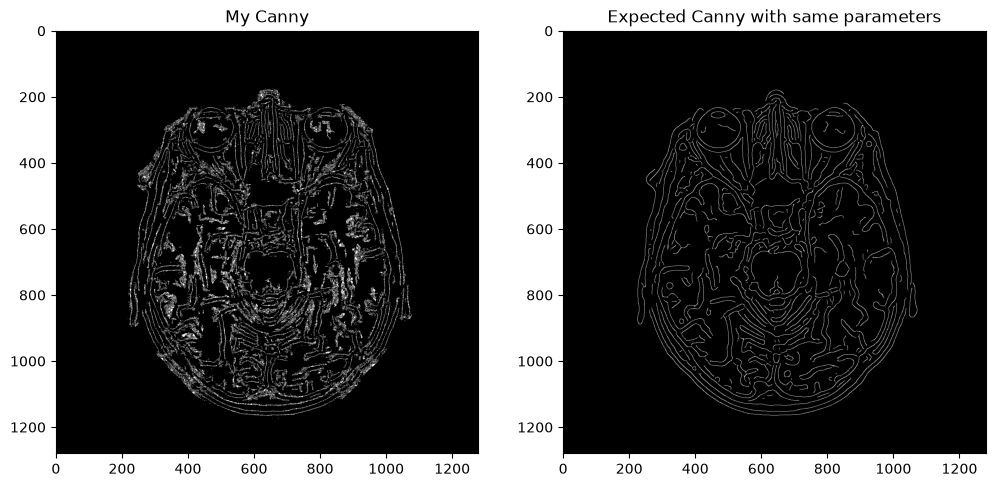

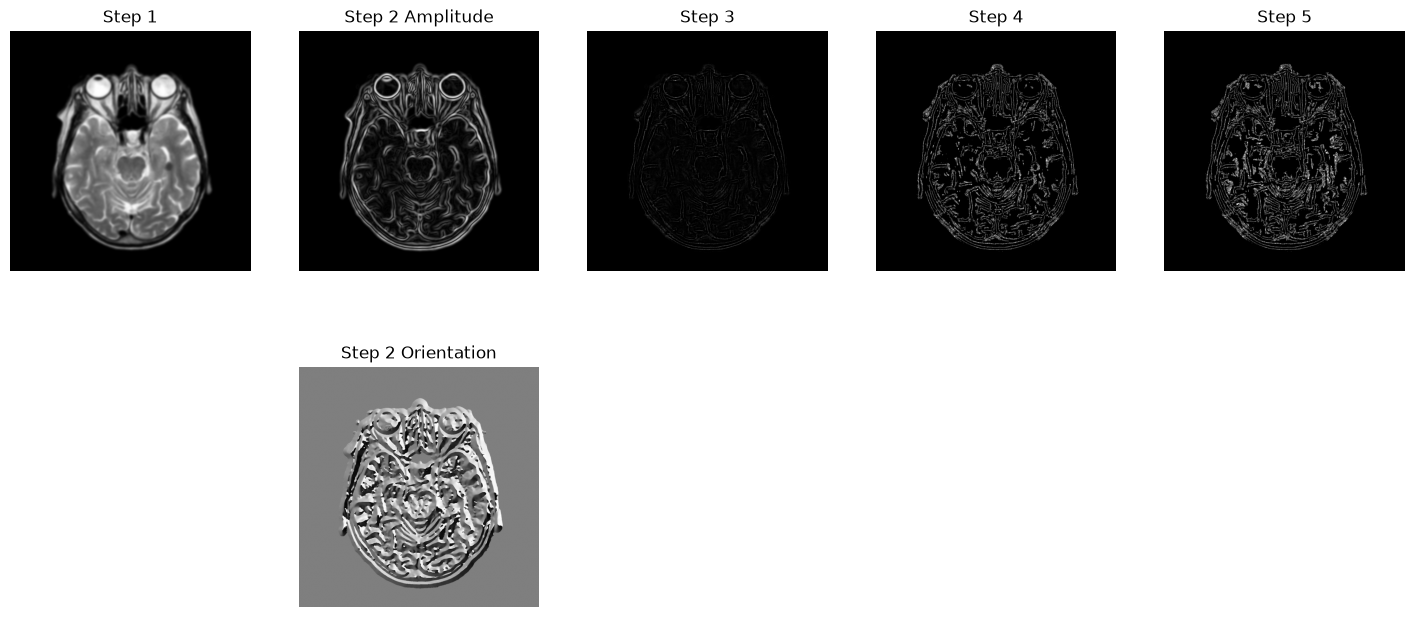

In [ ]:
from scipy import datasets, ndimage

def thinning(img, angles):
    """
    Parameters
    ----------
    img : numpy.ndarray
        2D image containing the gradient magnitudes on which the edges have to be thinned.
    angles : numpy.ndarray
        2D array of the same size as img, containing the gradient angles in radians.

    Returns
    -------
    numpy.ndarray
        Thinned image.
    """
    M, N = img.shape
    Z = np.zeros((M, N), dtype=np.int32)
    angle = angles * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, M - 1):
        for j in range(1, N - 1):

            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = img[i, j + 1]
                r = img[i, j - 1]

            elif (22.5 <= angle[i, j] < 67.5):
                q = img[i - 1, j + 1]
                r = img[i + 1, j - 1]

            elif (67.5 <= angle[i, j] < 112.5):
                q = img[i - 1, j]
                r = img[i + 1, j]

            elif (112.5 <= angle[i, j] < 157.5):
                q = img[i - 1, j - 1]
                r = img[i + 1, j + 1]

            if (img[i, j] >= q) and (img[i, j] >= r):
                Z[i, j] = img[i, j]
            else:
                Z[i, j] = 0
    return Z

def intensity_gradient(image):

    ascent = image.astype('int32')


    matrix_x = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
    matrix_y = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]

    Gx = convolve(ascent, np.flip(matrix_x))
    Gy = convolve(ascent, np.flip(matrix_y))

    expected_x = ndimage.sobel(ascent, 1)
    expected_y = ndimage.sobel(ascent, 0)

    G_matrix = np.hypot(Gx, Gy)

    expected_G = np.hypot(expected_x, expected_y)
    """
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    plt.gray()  # show the filtered result in grayscale
    axs[0, 0].imshow(ascent)
    axs[0, 1].imshow(Gx)
    axs[1, 0].imshow(Gy)
    axs[1, 1].imshow(G_matrix)
    titles = ["original", "horizontal", "vertical", "magnitude"]
    for i, ax in enumerate(axs.ravel()):
        ax.set_title(titles[i])
        ax.axis("off")
    """
    Theta = np.arctan2(Gy, Gx)
    expected_Theta = np.arctan2(expected_y, expected_x)
    

    print(" ### ")
    print("The difference between my Gx and the sobel's function is close enought to ceonsider them equals? ", np.allclose(Gx, expected_x))
    print("The difference between my Gx and the sobel's function is close enought to ceonsider them equals? ", np.allclose(Gy, expected_y))
    print("The calculate G and the Sobel's one are close enought? ", np.allclose(G_matrix, expected_G))
    print("The calculate Theta and the Sobel's one are close enought? ", np.allclose(Theta, expected_Theta))
    print(" ### ")
    
    return G_matrix, Theta

def double_threshold(values):
    strong_threshold = 0.1 * values.max()
    weak_threshold = 0.05 * values.max()

    print(f"Strong threshold is {strong_threshold} and weak is {weak_threshold} where max value is {np.max(values)}")

    strongs = np.where(values>=strong_threshold, 255, 0)
    weaks = np.where((values<strong_threshold) & (values>=weak_threshold), values, 0)
    return strongs, weaks

def weak_border_verification(strong, weak):
    print(" *** Verifiyng the weak borders (step 5) *** ")

    strong_points = np.transpose(np.nonzero(strong))

    queue = deque(strong_points.astype(np.int32))

    while len(queue) != 0:
        current = queue.popleft()
        i, j = current
        if i >= 1 and i + 2 < strong.shape[0] and j >= 1 and j +2< strong.shape[1]:
            weak_neighbours = np.transpose(np.nonzero(weak[i-1:i+2, j-1:j+2]))
            coordinates = np.array([(row, col) for row in range(i-1, i+2) for col in range(j-1, j+2)]).reshape(3, 3, 2)
            coordinates[coordinates < 0] = 0
            if len(weak_neighbours) > 0: # There are many weak neighbours next to this strong point
                print(" ################ ")
                print(f"We are considering the current point: {current}, that have coordinates i, j: {i, j}.")
                print(f"The matrix of the 9 neighbour coordinates is: ")
                for lines in coordinates:
                    print(f"{lines[0]} {lines[1]} {lines[2]}")
                print(f"It's weak neighbours are: {weak_neighbours}")
                for element in weak_neighbours:
                    if [element[0], element[1]] != [1, 1]:
                        corrected_coordinates = coordinates[element[0], element[1]]
                        print(f"The relative position of the weak point is {element}, so the corrected coordinates are : {corrected_coordinates}")
                        print(f"The value in weak matrix at position {corrected_coordinates} is {weak[corrected_coordinates[0], corrected_coordinates[1]]} ")
                        print(f"The value in strong matrix at position {corrected_coordinates} is {strong[corrected_coordinates[0], corrected_coordinates[1]]} ")
                        strong[corrected_coordinates] = 255
                        print("After affectation: ")
                        print(f"The value in strong matrix at position {corrected_coordinates} is {strong[corrected_coordinates[0], corrected_coordinates[1]]} ")
                        queue.append(corrected_coordinates.astype(np.int32))
                        weak[corrected_coordinates] = 0
                        print(f"The value in weak matrix at position {corrected_coordinates} is {weak[corrected_coordinates[0], corrected_coordinates[1]]} ")
    
    strong = strong.astype(np.uint8)
    weak[weak > 0] = 0
    print(f"La matrice strong contient ces valeurs: {np.unique_counts(strong)}")

    print("All strong coordinates have been visited")
    return strong, weak

from collections import deque
import numpy as np


def weak_border_verification_IA(strong, weak):
    """
    Conserve les pixels faibles connectés à au moins un pixel fort.

    Paramètres
    ----------
    strong : np.ndarray
        Masque des pixels forts. Les valeurs non nulles sont considérées
        comme des pixels forts.

    weak : np.ndarray
        Masque des pixels faibles. Les valeurs non nulles sont considérées
        comme des pixels faibles.

    Retour
    ------
    strong_result : np.ndarray
        Image binaire uint8 : 255 pour les contours conservés, 0 ailleurs.

    weak_result : np.ndarray
        Image des pixels faibles non conservés. Ici, elle est entièrement
        mise à zéro après l'hystérésis.
    """

    if strong.shape != weak.shape:
        raise ValueError("strong et weak doivent avoir la même forme.")

    strong_result = strong.copy()
    weak_result = weak.copy()

    height, width = strong_result.shape

    strong_points = np.argwhere(strong_result > 0)
    queue = deque(map(tuple, strong_points))

    neighbours = (
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    )

    while queue:
        i, j = queue.popleft()

        for di, dj in neighbours:
            ni = i + di
            nj = j + dj

            if ni < 0 or ni >= height or nj < 0 or nj >= width:
                continue

            if weak_result[ni, nj] > 0:
                strong_result[ni, nj] = 255
                weak_result[ni, nj] = 0
                queue.append((ni, nj))

    strong_result = np.where(strong_result > 0, 255, 0).astype(np.uint8)
    weak_result = np.zeros_like(weak_result)

    return strong_result, weak_result


def my_canny(image):

    cols = ["Step {}".format(step) for step in range(1, 6)]

    fig, axs = plt.subplots(2, 5, figsize=(18, 8))

    for ax, col in zip(axs[0], cols):
        ax.set_title(col)
    
    for i, axe in enumerate(axs.ravel()):
        axe.axis("off")

    step_one = gaussian_filter(image, sigma=5)
    axs[0, 0].imshow(step_one)

    step_two = intensity_gradient(step_one) # Returned: G and Theta matrixes 
    axs[0, 1].imshow(step_two[0])
    axs[0, 1].set_title(cols[1] + " Amplitude")
    axs[1, 1].imshow(step_two[1])
    axs[1, 1].set_title(cols[1] + " Orientation")

    step_three = thinning(step_two[0], step_two[1])
    axs[0,2].imshow(step_three)

    step_four = double_threshold(step_three)
    print(f"In step 4 there was {np.count_nonzero(step_four[0] > 0)} strong points")
    axs[0, 3].imshow(step_four[0])

    step_five = weak_border_verification_IA(step_four[0], step_four[1])
    axs[0, 4].imshow(step_five[0])
    print(f"In step 5: {np.count_nonzero(step_five[1] > 0)} weak")
    
    return step_five[0] > 0

fig, axs = plt.subplots(1, 2)

axs[0].imshow(my_canny(img_brain), cmap="gray")
axs[0].set_title("My Canny")


from skimage.feature import canny as expected_canny
step_one = gaussian_filter(img_brain, sigma=5)
step_two = intensity_gradient(step_one)
step_three = thinning(step_two[0], step_two[1])

reference_edges = expected_canny(
    img_brain,
    sigma=5,
    low_threshold=0.05 * step_three.max(),
    high_threshold=0.1 * step_three.max(),
)

axs[1].imshow(reference_edges, cmap="gray")
axs[1].set_title("Expected Canny with same parameters")


fig.set_figheight(7)
fig.set_figwidth(12)
plt.show()




<div class="alert alert-info">

### QUESTION 2
Explain how the `thinning()` function works for the step 3. 

<div class="alert alert-info">

### QUESTION 3
How does the strong and weak thresholds in step 4 influence the final detected edges ? 

<div class="alert alert-info">

### BONUS QUESTION
Show the resulting borders in color on top of the original images. 